# Growth Factor: Numerical Solver vs Fitting Functions

This notebook compares numerical and analytic approaches to computing the linear growth factor $D(z)/D(0)$.

## Background

The linear growth factor $D(a)$ satisfies the ODE (in terms of scale factor $a$):

$$D''(a) + \left(\frac{3}{a} + \frac{E'(a)}{E(a)}\right)D'(a) = \frac{3\Omega_{m,0}}{2\,a^5\,E(a)^2}\,D(a), \qquad E(a)=H(a)/H_0$$

with primes denoting $d/da$ and growing-mode initial condition $D \sim a$ deep in matter domination.

## Implemented solvers

| Solver key | Method / equation | Cosmology support |
|---|---|---|
| `solveODE` | Full numerical integration of the ODE above | Any DE via `Omega_DE(z)` |
| `Hamilton2000` | $D(z) = H(z)\displaystyle\int_0^{a} \frac{da'}{(a'H(a'))^3}$ &emsp; *(Heath 1977 / Hamilton 2001)* | **ΛCDM only**; 3–10% error for $w\neq-1$ |
| `Linder2005` | $D(z) = \dfrac{1}{1+z}\exp\!\left[\int_0^{a}\dfrac{\Omega_m(a')^{\gamma}-1}{a'}\,da'\right]$, $\quad\gamma\approx0.55+0.05(1+w)$ | Most dynamical DE |
| `CPT` | $D(z) = \dfrac{g(\Omega_m(z),\Omega_\Lambda(z))}{(1+z)\,g(\Omega_{m,0},\Omega_{\Lambda,0})}$, $\quad g = \dfrac{5\Omega_m/2}{\Omega_m^{4/7}-\Omega_\Lambda+(1+\tfrac{\Omega_m}{2})(1+\tfrac{\Omega_\Lambda}{70})}$ &emsp; *(Carroll, Press & Turner 1992)* | Flat ΛCDM only |

> **Note on `Hamilton2000`:** The integral formula treats $H(a)$ as the homogeneous decaying-mode solution to the growth ODE. $H(a)$ satisfies the growth ODE **only when $w=-1$** (ΛCDM). For WCDM/CPL ($w\neq-1$) the formula is no longer exact and produces **3–10% errors** (see §2). The default solver is `Linder2005`, which works accurately for both ΛCDM and dynamical dark energy.

## Sections
1. [ΛCDM — all methods agree (for $z \lesssim 30$)](#lcdm)
2. [CPL dark energy — Hamilton fails, Linder works](#cpl)
3. [WDM — linear growth factor is unchanged](#wdm)
4. [Failure modes — error vs $w$](#failure)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import toolscosmo as tc

# Redshift range relevant for cosmic dawn (z_max ~ 30)
z = np.logspace(-2, np.log10(30), 300)

def Dz(param, solver, z=z):
    param.code.Dz_solver = solver
    return tc.growth_factor(z, param)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

---
<a id='lcdm'></a>
## 1. ΛCDM

For flat ΛCDM all four methods should agree. Residuals shown relative to the ODE solver (reference).

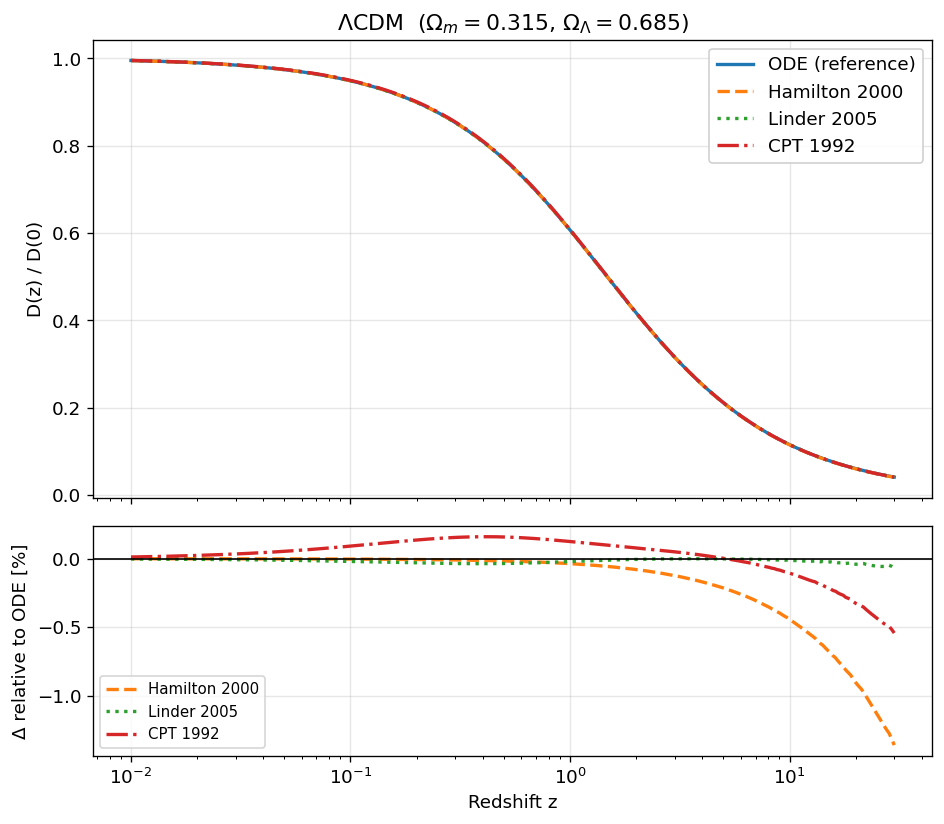

In [2]:
param_lcdm = tc.par(DM='LCDM', DE='LCDM')
param_lcdm.cosmo.solver = 'toolscosmo'

D_lcdm = {
    'ODE (reference)' : Dz(param_lcdm, 'solveODE'),
    'Hamilton 2000'   : Dz(param_lcdm, 'Hamilton2000'),
    'Linder 2005'     : Dz(param_lcdm, 'Linder2005'),
    'CPT 1992'        : Dz(param_lcdm, 'CPT'),
}

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})
ax, axr = axes
colors = ['C0', 'C1', 'C2', 'C3']
ls_list = ['-', '--', ':', '-.']
D_ref = D_lcdm['ODE (reference)']

for (label, D), c, ls in zip(D_lcdm.items(), colors, ls_list):
    ax.plot(z, D, label=label, color=c, ls=ls, lw=2)
    if label != 'ODE (reference)':
        axr.plot(z, (D - D_ref)/D_ref * 100, color=c, ls=ls, lw=2, label=label)

ax.set_ylabel('D(z) / D(0)')
ax.set_title(r'ΛCDM  ($\Omega_m=0.315$, $\Omega_\Lambda=0.685$)')
ax.legend(framealpha=0.9)
ax.set_xscale('log')

axr.axhline(0, color='k', lw=1)
axr.set_xlabel('Redshift z')
axr.set_ylabel('Δ relative to ODE [%]')
axr.legend(fontsize=9)

plt.tight_layout()
#plt.savefig('growth_factor_LCDM.png', bbox_inches='tight')
plt.show()

**Result (for $0 \leq z \leq 30$):**
- **Hamilton 2000** agrees with ODE to $\lesssim 0.5\%$ (residual is dominated by ODE numerical discretisation).
- **Linder 2005** is $\lesssim 0.1\%$ — best accuracy of the three fitting methods.
- **CPT 1992** is $\lesssim 0.2\%$ (calibrated for flat ΛCDM).

All methods degrade at $z \gg 30$ where the ODE grid becomes coarser; for cosmic-dawn applications ($z \leq 30$) all four are reliable for ΛCDM.

---
<a id='cpl'></a>
## 2. CPL dark energy

CPL parameterisation: $w(a) = w_0 + w_a(1 - a)$.  
Setting $w_a = 0$ reduces CPL to a constant-$w$ (WCDM) model.  
The ODE solver and Linder (2005) are both designed for this regime; Hamilton (2000) is not.

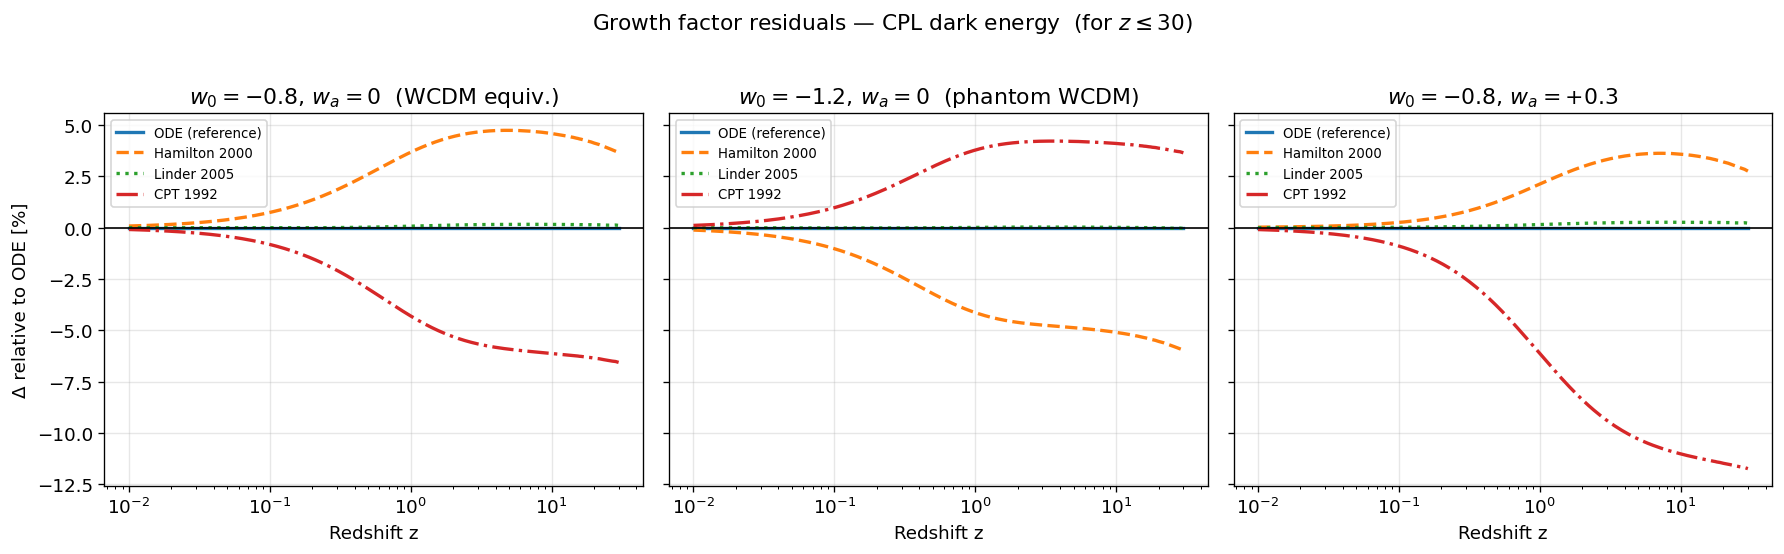

In [3]:
# CPL cases: the first two have wa=0 (equivalent to WCDM) to show Hamilton failure;
# the third has non-zero wa.
cpl_cases = [
    {'w0': -0.8, 'wa':  0.0, 'label': r'$w_0=-0.8,\,w_a=0$  (WCDM equiv.)'},
    {'w0': -1.2, 'wa':  0.0, 'label': r'$w_0=-1.2,\,w_a=0$  (phantom WCDM)'},
    {'w0': -0.8, 'wa':  0.3, 'label': r'$w_0=-0.8,\,w_a=+0.3$'},
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, case in zip(axes, cpl_cases):
    param_cpl = tc.par(DM='LCDM', DE='CPL')
    param_cpl.cosmo.solver = 'toolscosmo'
    param_cpl.DE.w0 = case['w0']
    param_cpl.DE.wa = case['wa']

    D_cpl = {
        'ODE (reference)' : Dz(param_cpl, 'solveODE'),
        'Hamilton 2000'   : Dz(param_cpl, 'Hamilton2000'),
        'Linder 2005'     : Dz(param_cpl, 'Linder2005'),
        'CPT 1992'        : Dz(param_cpl, 'CPT'),
    }
    D_ref = D_cpl['ODE (reference)']

    colors = ['C0', 'C1', 'C2', 'C3']
    ls_list = ['-', '--', ':', '-.']
    for (label, D), c, ls in zip(D_cpl.items(), colors, ls_list):
        rel = (D - D_ref) / D_ref * 100
        ax.plot(z, rel, label=label, color=c, ls=ls, lw=2)

    ax.axhline(0, color='k', lw=1)
    ax.set_xscale('log')
    ax.set_xlabel('Redshift z')
    if ax == axes[0]:
        ax.set_ylabel('Δ relative to ODE [%]')
    ax.set_title(case['label'])
    ax.legend(fontsize=8)

plt.suptitle('Growth factor residuals — CPL dark energy  (for $z \\leq 30$)',
             fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig('growth_factor_CPL.png', bbox_inches='tight')
plt.show()

**Result (for $0 \leq z \leq 30$):**
- **Hamilton 2000** deviates by **3–10%** whenever $w \neq -1$.  
  The error grows with redshift and with $|w + 1|$ — Hamilton is unreliable for any dynamical dark energy model.
- **Linder 2005** remains $\lesssim 0.3\%$ across all CPL cases shown — best choice for non-ΛCDM.
- **CPT 1992** degrades in the same way as Hamilton for $w \neq -1$ (calibrated for $\Omega_\Lambda = \text{const}$).

---
<a id='wdm'></a>
## 3. WDM — linear growth factor

In standard warm dark matter models (thermal relics), the **background expansion** is identical
to CDM: the WDM particle mass does not affect $H(z)$.  
Consequently, **all growth factor solvers return the same $D(z)$** for WDM as for CDM.

The observational WDM signature enters through the **power spectrum** via the free-streaming
suppression (Viel et al. 2005):
$$P_\text{WDM}(k) = T^2_{\rm WDM}(k)\, P_\text{CDM}(k), \qquad
T_\text{WDM}(k) = \bigl[1 + (\alpha k)^{2\mu}\bigr]^{-5/\mu}, \quad \mu=1.12$$
$$\alpha \;[\text{Mpc}/h] = 0.049\,\left(\frac{m_\text{WDM}}{1\,\text{keV}}\right)^{-1.11}
\!\left(\frac{\Omega_\text{WDM}}{0.25}\right)^{0.11}\!\left(\frac{h}{0.7}\right)^{1.22}$$

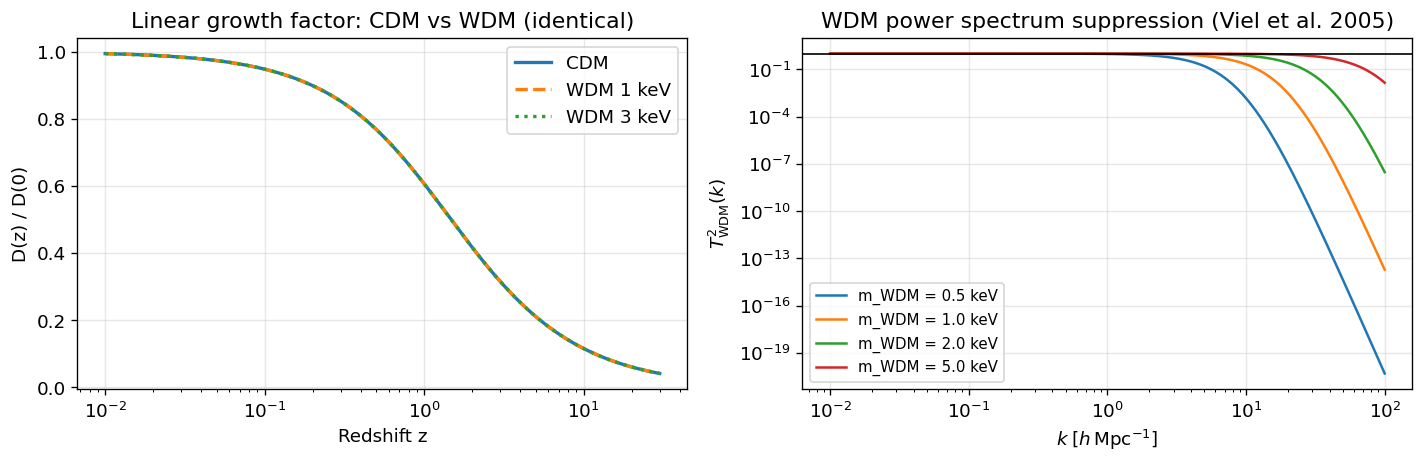

Max |D_WDM - D_CDM| / D_CDM = 0.00e+00 %  (numerical noise only)


In [4]:
param_cdm  = tc.par(DM='LCDM', DE='LCDM'); param_cdm.cosmo.solver  = 'toolscosmo'
param_wdm1 = tc.par(DM='WDM',  DE='LCDM'); param_wdm1.cosmo.solver = 'toolscosmo'; param_wdm1.DM.m_wdm = 1.0
param_wdm3 = tc.par(DM='WDM',  DE='LCDM'); param_wdm3.cosmo.solver = 'toolscosmo'; param_wdm3.DM.m_wdm = 3.0

D_cdm  = Dz(param_cdm,  'solveODE')
D_wdm1 = Dz(param_wdm1, 'solveODE')
D_wdm3 = Dz(param_wdm3, 'solveODE')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(z, D_cdm,  label='CDM',        color='C0', lw=2)
ax.plot(z, D_wdm1, label='WDM 1 keV', color='C1', lw=2, ls='--')
ax.plot(z, D_wdm3, label='WDM 3 keV', color='C2', lw=2, ls=':')
ax.set_xscale('log')
ax.set_xlabel('Redshift z'); ax.set_ylabel('D(z) / D(0)')
ax.set_title('Linear growth factor: CDM vs WDM (identical)')
ax.legend()

# Transfer function suppression
def alpha_wdm(m_wdm_keV, Omega_wdm=0.315, h0=0.673):
    return 0.049 * m_wdm_keV**(-1.11) * (Omega_wdm/0.25)**0.11 * (h0/0.7)**1.22

def T_wdm_sq(k, m_wdm_keV, mu=1.12):
    al = alpha_wdm(m_wdm_keV)
    return (1 + (al * k)**(2*mu))**(-10/mu)

k = np.logspace(-2, 2, 500)
ax2 = axes[1]
for m in [0.5, 1.0, 2.0, 5.0]:
    ax2.plot(k, T_wdm_sq(k, m), label=f'm_WDM = {m} keV')
ax2.axhline(1, color='k', lw=1)
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax2.set_ylabel(r'$T^2_\mathrm{WDM}(k)$')
ax2.set_title('WDM power spectrum suppression (Viel et al. 2005)')
ax2.legend(fontsize=9)

plt.tight_layout()
#plt.savefig('growth_factor_WDM.png', bbox_inches='tight')
plt.show()

max_diff = np.max(np.abs(D_wdm1 - D_cdm) / D_cdm) * 100
print(f'Max |D_WDM - D_CDM| / D_CDM = {max_diff:.2e} %  (numerical noise only)')

**Result:** The linear growth factor is numerically identical between CDM and WDM (difference is floating-point noise only).  
WDM suppresses power only at $k \gtrsim 1/\alpha$, which for $m_\text{WDM} = 1\,\text{keV}$ corresponds to $k \sim 10\,h/\text{Mpc}$.

---
<a id='failure'></a>
## 4. Failure modes — error vs $w$

Sweep $w$ from $-0.5$ to $-1.5$ and quantify each method's deviation from the ODE solver at $z \leq 30$.

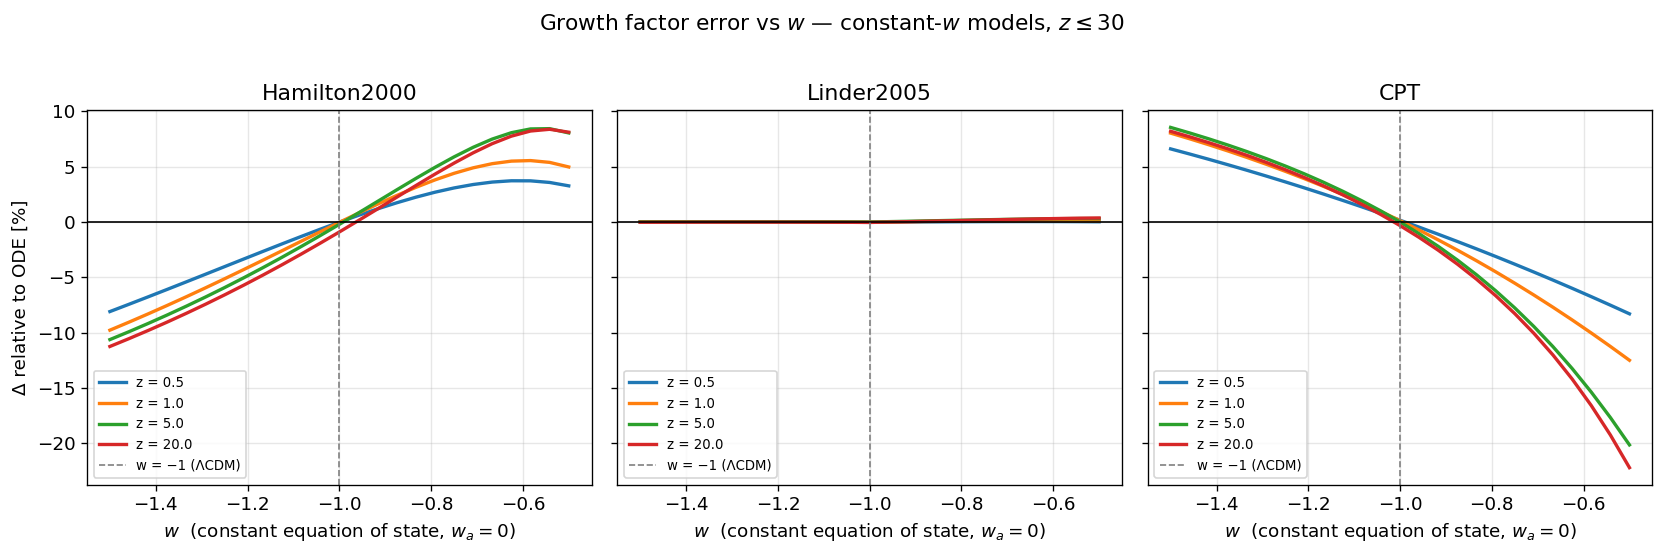

In [5]:
w_vals = np.linspace(-0.5, -1.5, 25)
z_test = np.array([0.5, 1.0, 5.0, 20.0])  # representative z ≤ 30

results = {solver: {str(zi): [] for zi in z_test}
           for solver in ['Hamilton2000', 'Linder2005', 'CPT']}

for w in w_vals:
    p = tc.par(DM='LCDM', DE='CPL')
    p.cosmo.solver = 'toolscosmo'
    p.DE.w0 = w; p.DE.wa = 0.0   # wa=0 → constant w (WCDM equivalent)
    D_ref = Dz(p, 'solveODE', z=z_test)
    for solver in results:
        D_s = Dz(p, solver, z=z_test)
        for i, zi in enumerate(z_test):
            results[solver][str(zi)].append((D_s[i] - D_ref[i]) / D_ref[i] * 100)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
colors_z = ['C0', 'C1', 'C2', 'C3']

for ax, solver in zip(axes, results):
    for zi, c in zip(z_test, colors_z):
        ax.plot(w_vals, results[solver][str(zi)], color=c, lw=2, label=f'z = {zi}')
    ax.axhline(0, color='k', lw=1)
    ax.axvline(-1, color='grey', lw=1, ls='--', label='w = −1 (ΛCDM)')
    ax.set_xlabel('$w$  (constant equation of state, $w_a = 0$)')
    if ax == axes[0]:
        ax.set_ylabel('Δ relative to ODE [%]')
    ax.set_title(solver)
    ax.legend(fontsize=8)

plt.suptitle('Growth factor error vs $w$ — constant-$w$ models, $z \\leq 30$',
             fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig('growth_factor_failure_modes.png', bbox_inches='tight')
plt.show()

**Result (for $z \leq 30$):**
- **Hamilton 2000** error grows linearly with $|w+1|$, reaching **5–10%** at $w = -0.5$ or $w = -1.5$.  
  The error also increases with redshift — worst at $z = 20$.
- **Linder 2005** stays below **0.5%** across the full $w$ range.
- **CPT 1992** shows errors comparable to Hamilton for $w \neq -1$.

---

## Summary

| Method | Cosmology support | Accuracy ($z \leq 30$) | Notes |
|---|---|---|---|
| **ODE** (`solveODE`) | Any DE via `Omega_DE(z)` | reference | Slowest; numerical $E'(a)$; corrected sign and power of $a$ |
| **Hamilton 2000** | ΛCDM exact; ≤ 0.5% | **3–10% for $w\neq-1$** | $H(a)$ is decaying mode only for $w=-1$ — use ODE or Linder for dynamical DE |
| **Linder 2005** *(default)* | ΛCDM, WCDM, CPL, most DDE | $\lesssim 0.5\%$ | Best overall choice — accurate for both ΛCDM and dynamical DE |
| **CPT 1992** | Flat ΛCDM | $\lesssim 0.2\%$ for ΛCDM | Significant errors for $w \neq -1$ |

### Recommendations
- **Default (`Linder2005`)**: reliable for ΛCDM and most dynamical DE, $z \leq 30$.
- **Use `solveODE`** for exotic DE (growing neutrino mass, ULA, custom $w(z)$) or when sub-0.1% precision is needed.
- **Avoid `Hamilton2000`** for $w \neq -1$ — errors are 3–10% and grow with redshift.